# ARIMA models

## ARIMA models

|        |                                                     |
|--------|-----------------------------------------------------|
| **AR** | autoregressive (lagged observations as inputs)      |
| **I**  | integrated (differencing to make series stationary) |
| **MA** | moving average (lagged errors as inputs)            |

---

An ARIMA model is rarely interpretable in terms of visible data structures like trend and seasonality. But it can capture a huge range of time series patterns.

# Stationarity and differencing

## Stationarity

**Definition**
If $\{y_t\}$ is a stationary time series, then for all $s$, the distribution of $(y_t,\dots,y_{t+s})$ does not depend on $t$.

---

A **stationary series** is:

* roughly horizontal
* constant variance
* no patterns predictable in the long-term


In [1]:
import pandas as pd
import rdatasets
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pmdarima as pmd
import seaborn as sns

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
goog = pd.read_csv('data/gafa_stock.csv').query("Symbol == 'GOOG'")
goog = goog.set_index(pd.to_datetime(goog.Date, format='%Y-%m-%d'))

In [3]:
strikes = pd.read_excel('data/strikes-annual-listing.xlsx', skiprows=2)
strikes = strikes.loc[:71, strikes.columns[:2]].astype(int)
strikes.columns = 'Year', 'Count'

In [4]:
housing = pd.read_csv('data/enigma-us.gov_.census.eits_.ressales-'
                'e7513e56d76050c05caf638306055c98_1.csv')

housing.loc[(housing['dt_code']=='TOTAL')&(housing['cat_code']=='SOLD')&(housing['geo_desc']=='United States')]

,per_idx,per_name,cat_idx,cat_code,cat_desc,cat_indent,dt_idx,dt_code,dt_desc,dt_unit,et_idx,et_code,et_desc,et_unit,geo_idx,geo_code,geo_desc,is_adj,val,serialid
4,1,1963-01-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,42.0,5
14,2,1963-02-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,35.0,15
24,3,1963-03-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,44.0,25
34,4,1963-04-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,52.0,35
44,5,1963-05-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,58.0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20154,642,2016-06-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,50.0,20155
20206,643,2016-07-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,54.0,20207
20258,644,2016-08-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,47.0,20259
20310,645,2016-09-01,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,45.0,20311


In [5]:
housing = housing.loc[(housing['dt_code']=='TOTAL')&(housing['cat_code']=='SOLD')&(housing['geo_desc']=='United States')].copy()
housing.rename(columns={'per_name': 'date', 'val': 'Count'}, inplace=True)
housing['date'] = pd.to_datetime(housing['date'])
housing.set_index('date', inplace=True)

In [6]:
housing

,per_idx,cat_idx,cat_code,cat_desc,cat_indent,dt_idx,dt_code,dt_desc,dt_unit,et_idx,et_code,et_desc,et_unit,geo_idx,geo_code,geo_desc,is_adj,Count,serialid
date,,,,,,,,,,,,,,,,,,,
1963-01-01,1,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,42.0,5
1963-02-01,2,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,35.0,15
1963-03-01,3,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,44.0,25
1963-04-01,4,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,52.0,35
1963-05-01,5,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,58.0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-06-01,642,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,50.0,20155
2016-07-01,643,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,54.0,20207
2016-08-01,644,1,SOLD,New Single-family Houses Sold,0,1,TOTAL,All Houses,K,0,NaN,NaN,NaN,1,US,United States,0,47.0,20259


In [7]:
housing = housing[['Count']]

In [8]:
us_econ = pd.read_csv('data/global_economy.csv')
us_econ = (
    us_econ
    .query("Code == 'USA'")
    .assign(date=pd.to_datetime(us_econ.Year, format='%Y'))
    .set_index('date')
)

In [9]:
eggs = pd.read_csv('data/eggs.csv')
eggs.columns = 'date', 'EggPrice'
eggs = (
    eggs
    .set_index(pd.to_datetime(eggs.date))
    .join(us_econ.resample('1MS').max().fillna(method='ffill'))
)

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/2218878464.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .join(us_econ.resample('1MS').max().fillna(method='ffill'))


In [10]:
d = pd.read_csv('data/aus_livestock.csv')
vic_pigs = (
    d
    .assign(date = pd.to_datetime(d.Month, format='%Y %b'))
    .query("Animal == 'Pigs' and State == 'Victoria'")
    .groupby('date Animal'.split())
    .Count.sum().reset_index()
    .set_index('date')
)

In [11]:
lynx = rdatasets.data('datasets', 'lynx')
lynx = (
    lynx
    .assign(date=pd.to_datetime(lynx.time, format='%Y'))
    .set_index('date')
)

In [12]:
d = pd.read_csv('data/aus_production.csv')
aus_production = (
    d
    .assign(Date=pd.to_datetime(d.Quarter.str.replace(' ', '')))
    .set_index('Date')
)
recent_production = aus_production.query("Date.dt.year >= 1992")


/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/4053886952.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(Date=pd.to_datetime(d.Quarter.str.replace(' ', '')))


In [13]:
def xdate(ax, fmt=None, freq=None):
    """Tweak x-axis date formatting."""
    dates = plt.matplotlib.dates
    if fmt is None:
        ax, fmt = plt.gca(), ax
    if freq:
        t1, t2 = dates.num2date(ax.get_xticks()[[0,-1]])
        ticks = pd.date_range(t1, t2, freq=freq)
        ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(dates.DateFormatter(fmt))

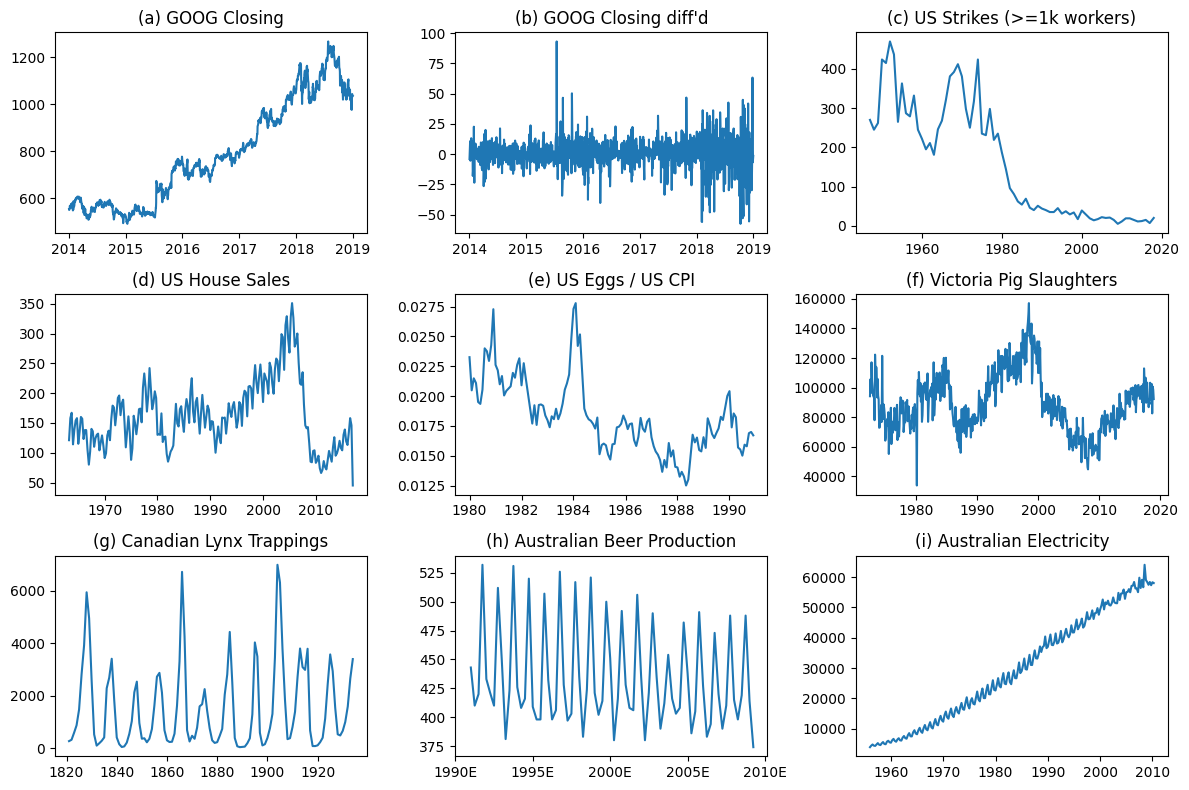

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(12,8))
axs = axs.ravel()
d = goog
axs[0].plot(d.Close)
axs[1].plot(d.Close.diff())

d = strikes
axs[2].plot(d.Year, d.Count)

d = housing
axs[3].plot(d.resample('1QE').sum().Count)

d = eggs
axs[4].plot((d.EggPrice / d.CPI).loc[:'1990'])

d = vic_pigs
axs[5].plot(d.Count)

d = lynx
axs[6].plot(d.value)

d = recent_production
axs[7].plot(d.Beer)

d = aus_production
axs[8].plot(d.Electricity)

titles = [
    'GOOG Closing',
    'GOOG Closing diff\'d',
    'US Strikes (>=1k workers)',
    'US House Sales',
    'US Eggs / US CPI',
    'Victoria Pig Slaughters',
    'Canadian Lynx Trappings',
    'Australian Beer Production',
    'Australian Electricity',
]
for (ax, title, letter) in zip(axs, titles, 'abcdefghi'):
    ax.set(title=f'({letter}) {title}')
xdate(axs[-2], '%YE', '5YE')
plt.tight_layout()


## Stationarity

**Definition**
If $\{y_t\}$ is a stationary time series, then for all $s$, the distribution of $(y_t,\dots,y_{t+s})$ does not depend on $t$.

---

Transformations help to **stabilize the variance**.

For ARIMA modelling, we also need to **stabilize the mean**.

## Non-stationarity in the mean

**Identifying non-stationary series**

* time plot
* The ACF of stationary data drops to zero relatively quickly
* The ACF of non-stationary data decreases slowly
* For non-stationary data, the value of $r_1$ is often large and positive


## Differencing

* Differencing helps to **stabilize the mean**.
* The differenced series is the *change* between each observation in the original series: $y'_t = y_t - y_{t-1}$.
* The differenced series will have only $T-1$ values since it is not possible to calculate a difference $y_1'$ for the first observation.

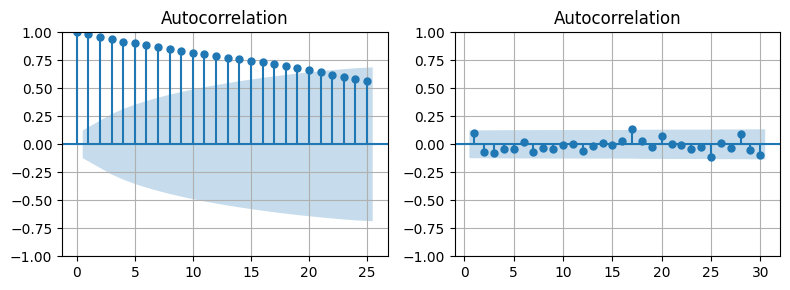

In [23]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8,3))
d = g15 = goog['2015':'2015']
sm.graphics.tsa.plot_acf(d.Close, ax=a1)
sm.graphics.tsa.plot_acf(d.Close.diff().dropna(), lags=np.r_[1:31], ax=a2)
[ax.grid(True) for ax in (a1,a2)]
plt.tight_layout()

## Random walk model

If differenced series is white noise with zero mean:


$$y_t-y_{t-1}=\varepsilon_t \hspace{0.4cm} or \hspace{0.4cm} y_t=y_{t-1}+\varepsilon_t$$
where $\varepsilon_t \sim NID(0,\sigma^2)$.

* Very widely used for non-stationary data.
* This is the model behind the **naïve method**.
* Random walks typically have:
    * long periods of apparent trends up or down
    * Sudden/unpredictable changes in direction
* Forecast are equal to the last observation
    * future movements up or down are equally likely.

## Random walk with drift model

If differenced series is white noise with non-zero mean:

$$y_t-y_{t-1}=c+\varepsilon_t \hspace{0.4cm} or \hspace{0.4cm} y_t=c+y_{t-1}+\varepsilon_t$$
where $\varepsilon_t \sim NID(0,\sigma^2)$.

* $c$ is the **average change** between consecutive observations.
* If $c>0$, $y_t$ will tend to drift upwards and vice versa.
* This is the model behind the \alert{drift method}.

## Second-order differencing

Occasionally the differenced data will not appear stationary and it may be necessary to difference the data a second time:\pause

$$\begin{align*}
y''_{t} & = y'_{t} - y'_{t - 1} \\
        & = (y_t - y_{t-1}) - (y_{t-1}-y_{t-2})\\
        & = y_t - 2y_{t-1} +y_{t-2}.
\end{align*}$$

* $y_t''$ will have $T-2$ values.
* In practice, it is almost never necessary to go beyond second-order differences.

## Seasonal differencing

A seasonal difference is the difference between an observation and the corresponding observation from the previous year.
$$
 y'_t = y_t - y_{t-m}
$$

where $m=$ number of seasons.

* For monthly data $m=12$.
* For quarterly data $m=4$.

In [24]:
pbs = pd.read_csv('data/PBS.csv', parse_dates=['Month'], date_format='%Y-%m-%d')
a10 = pbs.loc[pbs['ATC2']=='A10']
a10 = a10.groupby('Month')['Cost'].sum()
a10 = a10/1e6
a10 = a10.reset_index()
a10.set_index("Month", inplace=True, drop=False)
a10

,Month,Cost
Month,,
1991 Aug,1991 Aug,3.180891
1991 Dec,1991 Dec,4.306371
1991 Jul,1991 Jul,3.526591
1991 Nov,1991 Nov,3.565869
1991 Oct,1991 Oct,3.611003
...,...,...
2008 Feb,2008 Feb,21.654285
2008 Jan,2008 Jan,29.665356
2008 Jun,2008 Jun,19.431740


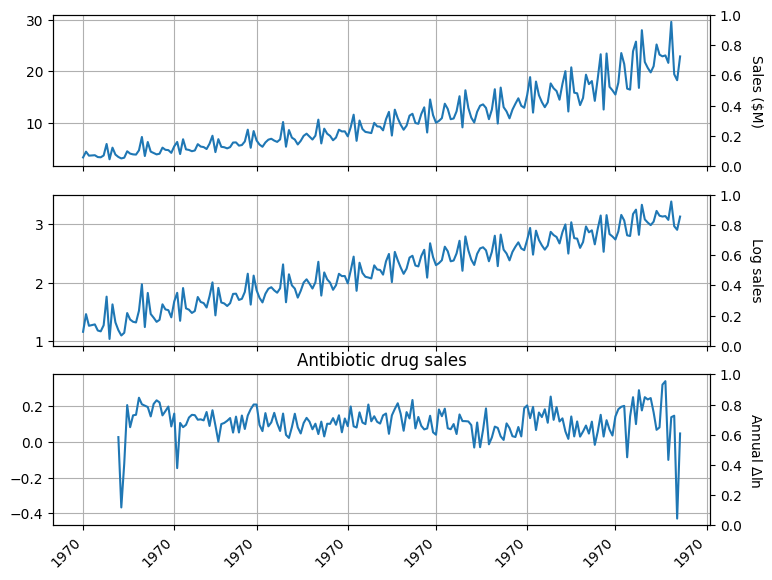

In [25]:
import matplotlib.dates as mdates
fig, axs = plt.subplots(3, 1, figsize=(8,6), sharex=True)
d = a10
axs[0].plot(d.Cost)
axs[1].plot(np.log(d.Cost))
axs[2].plot(np.log(d.Cost).diff(12))

titles = ['Sales ($M)', 'Log sales', 'Annual $\Delta\ln$']
for ax, title in zip(axs, titles):
    ax2 = ax.twinx()
    ax2.set_ylabel(title, rotation=270, labelpad=15)
    ax2.grid(False)
    ax.grid(True)


axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for label in axs[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')
plt.tight_layout()
plt.title('Antibiotic drug sales')

fig.subplots_adjust(top=.95)


In [26]:
h02 = pbs.loc[pbs['ATC2']=='H02'].groupby('Month').agg({'Cost': 'sum'})
h02['Cost'] = h02['Cost']/1e6


In [27]:
h02

,Cost
Month,
1991 Aug,0.400906
1991 Dec,0.602652
1991 Jul,0.429795
1991 Nov,0.502369
1991 Oct,0.492543
...,...
2008 Feb,0.761822
2008 Jan,1.219941
2008 Jun,0.762137


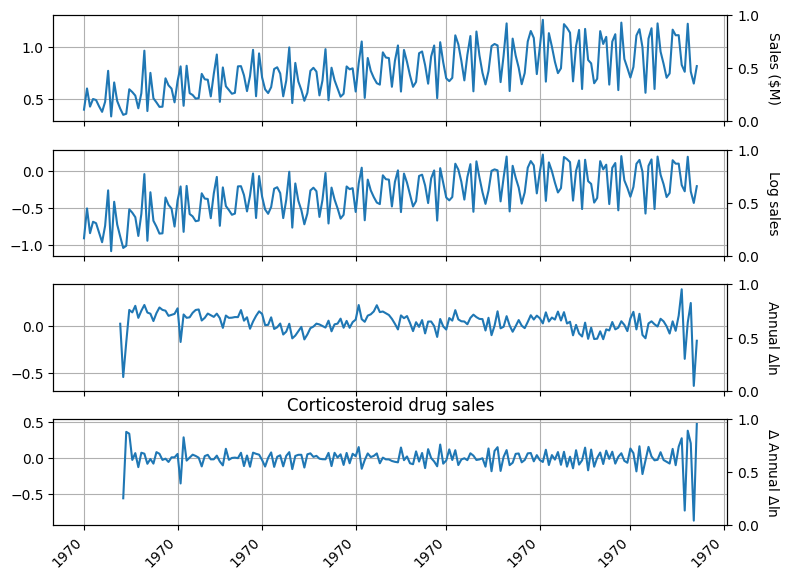

In [28]:
fig, axs = plt.subplots(4, 1, figsize=(8,6), sharex=True)
d = h02
axs[0].plot(d.Cost)
axs[1].plot(np.log(d.Cost))
axs[2].plot(np.log(d.Cost).diff(12))
axs[3].plot(np.log(d.Cost).diff(12).diff())
titles = 'Sales ($M)', 'Log sales', 'Annual $\Delta\ln$', '$\Delta$ Annual $\Delta\ln$'
for ax, title in zip(axs, titles):
    ax2 = ax.twinx()
    ax2.set_ylabel(title, rotation=270, labelpad=15)
    ax2.grid(False)
    ax.grid(True)


axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for label in axs[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')
plt.tight_layout()
plt.title('Corticosteroid drug sales')
fig.subplots_adjust(top=.95)

## Cortecosteroid drug sales

* Seasonally differenced series is closer to being stationary.
* Remaining non-stationarity can be removed with further first difference.

If $y'_t = y_t - y_{t-12}$ denotes seasonally differenced series, then twice-differenced series is

$$
\begin{align*}
y^*_t &= y'_t - y'_{t-1} \\
      &= (y_t - y_{t-12}) - (y_{t-1} - y_{t-13}) \\
      &= y_t - y_{t-1} - y_{t-12} + y_{t-13}\: .
\end{align*}
$$


## Seasonal differencing

When both seasonal and first differences are applied ...

* it makes no difference which is done first---the result will be the same.
* If seasonality is strong, we recommend that seasonal differencing be done first because sometimes the resulting series will be stationary and there will be no need for further first difference.

It is important that if differencing is used, the differences are interpretable.


## Interpretation of differencing

* first differences are the change between **one observation and the next**;
* seasonal differences are the change between **one year to the next**.


But taking lag 3 differences for yearly data, for example, results in a model which cannot be sensibly interpreted.

## Unit root tests

**Statistical tests to determine the required order of differencing.**

  1. Augmented Dickey Fuller test: null hypothesis is that the data are non-stationary and non-seasonal.
  2. Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test: null hypothesis is that the data are stationary and non-seasonal.
  3. Other tests available for seasonal data.

## KPSS test

### KPSS Test Output Explanation

| Output     | Description                                                                 |
|------------|-----------------------------------------------------------------------------|
| `stat`     | Test statistic calculated by the KPSS test.                                |
| `p_value`  | The p-value associated with the test statistic. Used to determine the result. |
| `lags`     | The number of lags used in the Newey-West estimator for the long-run variance. |
| `crit`     | Dictionary of critical values at 10%, 5%, 2.5%, and 1% significance levels. |

---

### KPSS Test Hypotheses

- **Null hypothesis (H₀)**: The series is stationary (around a mean or trend).
- **Alternative hypothesis (H₁)**: The series is not stationary (has a unit root / stochastic trend).

---

### Interpretation

- If **p-value < 0.05**: Reject H₀ → the series is **not stationary**.
- If **p-value ≥ 0.05**: Fail to reject H₀ → the series **may be stationary**.

---

### Regression Types

- `regression='c'`: Tests stationarity **around a constant (level stationarity)**.
- `regression='ct'`: Tests stationarity **around a trend (trend stationarity)**.

```python
from statsmodels.tsa.stattools import kpss
stat, p_value, lags, crit = kpss(series, regression='ct', nlags='auto')
```


In [29]:
# stat, p_value, lags, crit
sm.tsa.stattools.kpss(g15.Close, nlags='auto')

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/1044075919.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  sm.tsa.stattools.kpss(g15.Close, nlags='auto')


(2.009369275593288,
 0.01,
 10,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [30]:
sm.tsa.stattools.kpss(g15.Close.diff().diff().dropna(), nlags='auto')

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/3548254393.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  sm.tsa.stattools.kpss(g15.Close.diff().diff().dropna(), nlags='auto')


(0.30931181562645343,
 0.1,
 104,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [31]:
ndiffs, nsdiffs = pmd.arima.ndiffs, pmd.arima.nsdiffs

In [32]:
ndiffs(g15.Close), nsdiffs(g15.Close, 30)

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warning

(1, 0)

In [33]:
ndiffs(a10.Cost), ndiffs(h02.Cost), nsdiffs(a10.Cost, 12), nsdiffs(h02.Cost, 12)

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warning

(1, 1, 0, 1)

# Non-seasonal ARIMA models

## Autoregressive models

### Autoregressive (AR) models:
$$
  y_{t} = c + \phi_{1}y_{t - 1} + \phi_{2}y_{t - 2} + \cdots + \phi_{p}y_{t - p} + \varepsilon_{t},
$$

where $\varepsilon_t$ is white noise. This is a multiple regression with **lagged values** of $y_t$ as predictors.

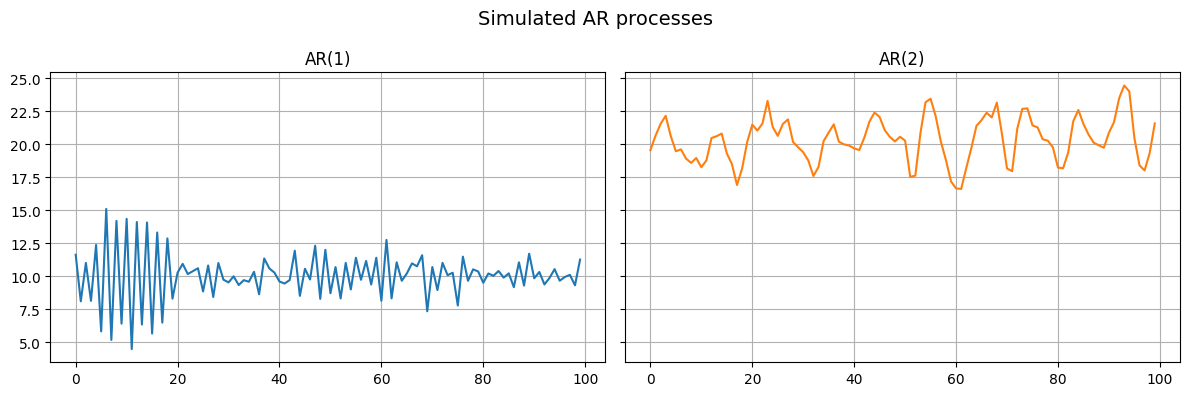

In [34]:
from statsmodels.tsa.arima_process import ArmaProcess
np.random.seed(1)

# AR(1): sim = 10 + arima.sim(list(ar = -0.8), n = 100)
ar1 = np.array([1, 0.8])
ma = np.array([1])
ar1_process = ArmaProcess(ar1, ma)
sim_ar1 = 10 + ar1_process.generate_sample(nsample=100)

# AR(2): sim = 20 + arima.sim(list(ar = c(1.3, -0.7)), n = 100)
ar2 = np.array([1, -1.3, 0.7])
ar2_process = ArmaProcess(ar2, ma)
sim_ar2 = 20 + ar2_process.generate_sample(nsample=100)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(sim_ar1, color='C0')
axs[0].set_title("AR(1)")
axs[0].set_ylabel("")
axs[0].grid(True)

axs[1].plot(sim_ar2, color='C1')
axs[1].set_title("AR(2)")
axs[1].set_ylabel("")
axs[1].grid(True)

fig.suptitle("Simulated AR processes", fontsize=14)
plt.tight_layout()
plt.show()

## AR(1) model


$$y_{t} = c + \phi_1 y_{t - 1} + \varepsilon_{t}$$

* When $\phi_1=0$, $y_t$ is **equivalent to WN**
* When $\phi_1=1$ and $c=0$, $y_t$ is **equivalent to a RW**
* When $\phi_1=1$ and $c\ne0$, $y_t$ is **equivalent to a RW with drift**
* When $\phi_1<0$, $y_t$ tends to **oscillate between positive and negative values**.

## Stationarity conditions

We normally restrict autoregressive models to stationary data, and then some constraints on the values of the parameters are required.

**General condition for stationarity**
  Complex roots of $1-\phi_1 z - \phi_2 z^2 - \dots - \phi_pz^p$ lie outside the unit circle on the complex plane.


* For $p=1$: $-1<\phi_1<1$.
* For $p=2$ <br> $-1<\phi_2<1\qquad \phi_2+\phi_1 < 1 \qquad \phi_2 -\phi_1 < 1$.
* More complicated conditions hold for $p\ge3$.
* Estimation software takes care of this.

## Moving Average (MA) models

### Moving Average (MA) models:
$$
  y_{t} = c + \varepsilon_t + \theta_{1}\varepsilon_{t - 1} + \theta_{2}\varepsilon_{t - 2} + \cdots + \theta_{q}\varepsilon_{t - q},
$$
where $\varepsilon_t$ is white noise.
This is a multiple regression with **past errors** as predictors. *Don't confuse this with moving average smoothing!*


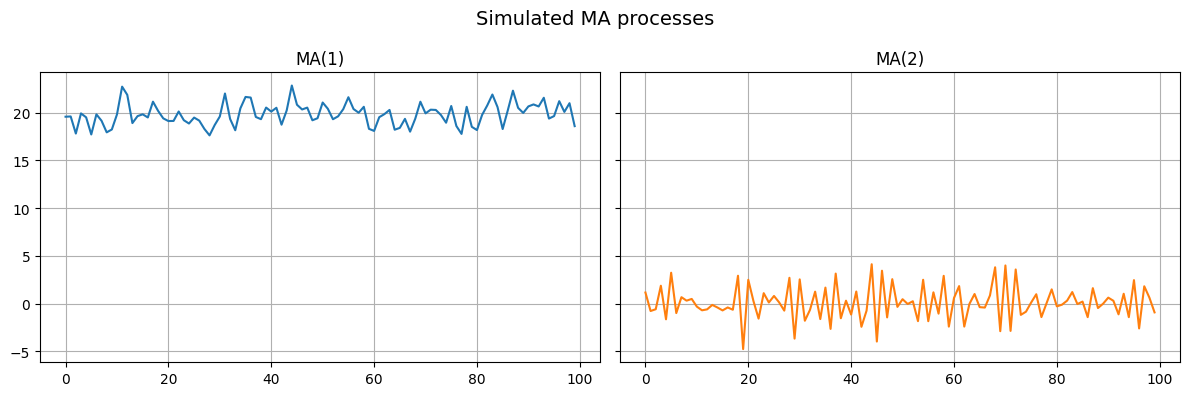

In [35]:
np.random.seed(2)

# MA(1): sim = 20 + arima.sim(list(ma = 0.8), n = 100)
ma1 = np.array([1, 0.8])
ma_process1 = ArmaProcess(np.array([1]), ma1)
sim_ma1 = 20 + ma_process1.generate_sample(nsample=100)

# MA(2): sim = arima.sim(list(ma = c(-1, +0.8)), n = 100)
ma2 = np.array([1, -1, 0.8])
ma_process2 = ArmaProcess(np.array([1]), ma2)
sim_ma2 = ma_process2.generate_sample(nsample=100)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(sim_ma1, color='C0')
axs[0].set_title("MA(1)")
axs[0].set_ylabel("")
axs[0].grid(True)

axs[1].plot(sim_ma2, color='C1')
axs[1].set_title("MA(2)")
axs[1].set_ylabel("")
axs[1].grid(True)

fig.suptitle("Simulated MA processes", fontsize=14)
plt.tight_layout()
plt.show()

## MA($\infty$) models

It is possible to write any stationary AR($p$) process as an MA($\infty$) process.

**Example: AR(1)**
$$\begin{align*}
y_t &= \phi_1y_{t-1} + \varepsilon_t\\
&= \phi_1(\phi_1y_{t-2} + \varepsilon_{t-1}) + \varepsilon_t\\
&= \phi_1^2y_{t-2} + \phi_1 \varepsilon_{t-1} + \varepsilon_t\\
&= \phi_1^3y_{t-3} + \phi_1^2\varepsilon_{t-2} + \phi_1 \varepsilon_{t-1} + \varepsilon_t\\
&\dots
\end{align*}$$
Provided $-1<\phi_1<1$:
$$y_t = \varepsilon_t + \phi_1\varepsilon_{t-1}+ \phi_1^2\varepsilon_{t-2}+ \phi_1^3\varepsilon_{t-3} + \cdots$$

## Invertibility

* Any MA($q$) process can be written as an AR($\infty$) process if we impose some constraints on the MA parameters.
* Then the MA model is called "invertible".
* Invertible models have some mathematical properties that make them easier to use in practice.
* Invertibility of an ARIMA model is equivalent to forecastability of an ETS model.

## Invertibility

### General condition for invertibility
  Complex roots of $1+\theta_1 z + \theta_2 z^2 + \dots + \theta_qz^q$ lie outside the unit circle on the complex plane.


* For $q=1$: $-1<\theta_1<1$.
* For $q=2$:
 <br> $-1<\theta_2<1\qquad \theta_2+\theta_1 >-1 \qquad \theta_1 -\theta_2 < 1$.
* More complicated conditions hold for $q\ge3$.
* Estimation software takes care of this.

## ARIMA models

### Autoregressive Moving Average models:

$$
y_{t} = c + \phi_{1}y_{t - 1} + \cdots + \phi_{p}y_{t - p} + \theta_{1}\varepsilon_{t - 1} + \cdots + \theta_{q}\varepsilon_{t - q} + \varepsilon_{t}
$$






* Predictors include both **lagged values of $y_t$ and lagged errors.**
* Conditions on AR coefficients ensure stationarity.
* Conditions on MA coefficients ensure invertibility.


### Autoregressive Integrated Moving Average models
* Combine ARMA model with **differencing**.
* $(1-B)^d y_t$ follows an ARMA model.

Where $B$ indicates the backshift notation
$$
  B y_{t} = y_{t - 1}
$$

## ARIMA models
>Autoregressive Integrated Moving Average models

### ARIMA($p, d, q$) model
|        |                                                     |
|--------|-----------------------------------------------------|
| **AR** | $p =$ order of the autoregressive part      |
| **I**  | $d =$ degree of first differencing involved |
| **MA** | $q =$ order of the moving average part            |

* White noise model: ARIMA(0,0,0)
* Random walk: ARIMA(0,1,0) with no constant
* Random walk with drift: ARIMA(0,1,0) with const.
* AR($p$): ARIMA($p$,0,0)
* MA($q$): ARIMA(0,0,$q$)

## Backshift notation for ARIMA

* ARMA model:\vspace*{-1cm}\newline

$$
y_{t} = c + \phi_{1}By_{t} + \cdots + \phi_pB^py_{t}
    + \varepsilon_{t} + \theta_{1}B\varepsilon_{t} + \cdots + \theta_qB^q\varepsilon_{t}$$

or
$$ y_{t} (1-\phi_1B - \cdots - \phi_p B^p) y_t = c + (1 + \theta_1 B + \cdots + \theta_q B^q)\varepsilon_t
$$

* ARIMA(1,1,1) model:

![](img/arima111.png)



$$\text{Expand:}\qquad
  y_t = c + y_{t-1} + \phi_1 y_{t-1}- \phi_1 y_{t-2} + \theta_1\varepsilon_{t-1} + \varepsilon_t
$$

In [36]:
!head 'data/us_change.csv'

Quarter,Consumption,Income,Production,Savings,Unemployment
1970 Q1,0.6185663995086799,1.0448013320120353,-2.452485526641013,5.299014070849051,0.9000000000000004
1970 Q2,0.4519840189008306,1.2256471921432421,-0.5514594737359158,7.789893824341565,0.5
1970 Q3,0.8728717804991959,1.5851538354837658,-0.35865175209615074,7.4039840659912315,0.5
1970 Q4,-0.27184793266723517,-0.23954486521731155,-2.185690872228596,1.1698982415315307,0.6999999999999993
1971 Q1,1.9013449590126186,1.9759249492860675,1.9097643638003259,3.5356669284715814,-0.09999999999999964
1971 Q2,0.9148773462618109,1.4459085282002349,0.9015695219955155,5.874763571619113,-0.09999999999999964
1971 Q3,0.794109641460139,0.5211491126242862,0.30803070805189847,-0.4062353413114117,0.09999999999999964
1971 Q4,1.6456331640359423,1.1591760935676376,2.2913621384764937,-1.4862589024096096,0
1972 Q1,1.3111896944382195,0.4568567139882518,4.154294954263493,-4.2919721958248225,-0.20000000000000018


In [37]:
us_change = pd.read_csv('data/us_change.csv')
us_change['date'] = pd.to_datetime(us_change.Quarter.str.replace(' ', ''))
us_change.set_index('date', inplace=True)
us_change.index.freq = pd.infer_freq(us_change.index)

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/1991602807.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  us_change['date'] = pd.to_datetime(us_change.Quarter.str.replace(' ', ''))


In [38]:
us_change

,Quarter,Consumption,Income,Production,Savings,Unemployment
date,,,,,,
1970-01-01,1970 Q1,0.618566,1.044801,-2.452486,5.299014,0.9
1970-04-01,1970 Q2,0.451984,1.225647,-0.551459,7.789894,0.5
1970-07-01,1970 Q3,0.872872,1.585154,-0.358652,7.403984,0.5
1970-10-01,1970 Q4,-0.271848,-0.239545,-2.185691,1.169898,0.7
1971-01-01,1971 Q1,1.901345,1.975925,1.909764,3.535667,-0.1
...,...,...,...,...,...,...
2018-04-01,2018 Q2,0.983112,0.661825,1.117424,-2.723974,0.0
2018-07-01,2018 Q3,0.853181,0.806271,1.256722,-0.085686,-0.3
2018-10-01,2018 Q4,0.356512,0.695142,0.948148,5.031337,0.2


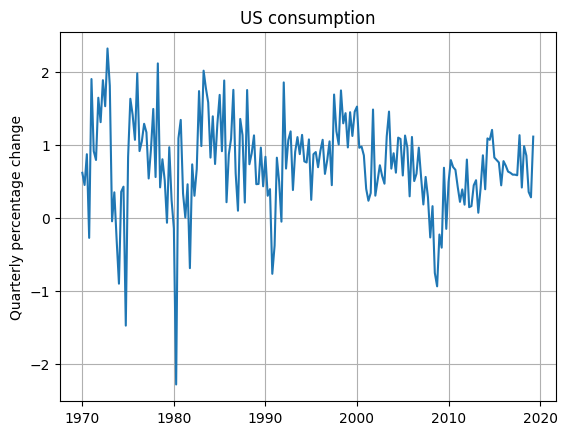

In [39]:
fig, ax = plt.subplots()
ax.plot(us_change.Consumption)
ax.set(ylabel='Quarterly percentage change')
ax.set_title('US consumption')
ax.grid(True)

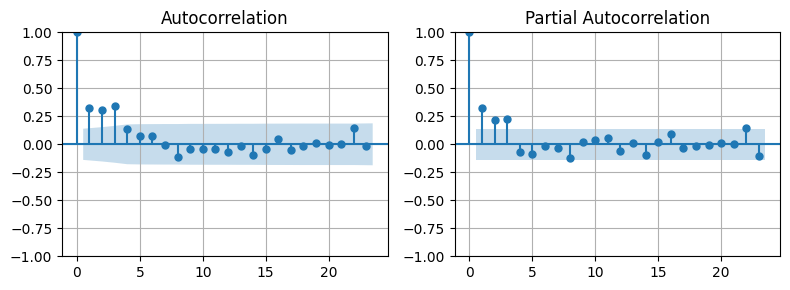

In [44]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8,3))
sm.graphics.tsa.plot_acf(us_change.Consumption, ax=a1)
sm.graphics.tsa.plot_pacf(us_change.Consumption, ax=a2)
[ax.grid(True) for ax in (a1,a2)]
plt.tight_layout()

In [40]:
from IPython.display import display, HTML


In [41]:
fit = sm.tsa.SARIMAX(us_change.Consumption, order=(1, 0, 3), trend='c').fit()
display(HTML(fit.summary().as_html()))

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.59351D-01    |proj g|=  5.49377D-02

At iterate    5    f=  8.58510D-01    |proj g|=  9.97379D-03

At iterate   10    f=  8.57994D-01    |proj g|=  3.64510D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6     12     16      1     0     0   2.733D-05   8.580D-01
  F =  0.85799421221562144     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


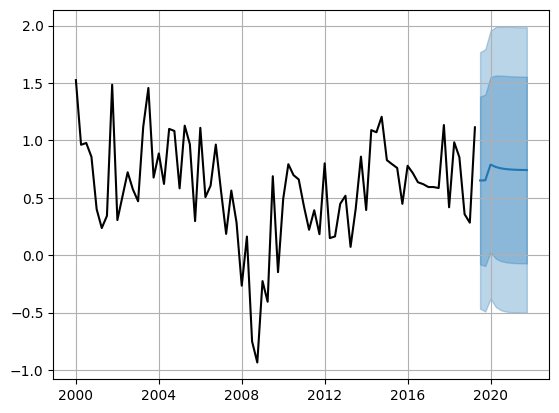

In [45]:
def ciclean(ci_df):
    """Clean up conf_int() result column names."""
    ci_df = ci_df.copy()
    ci_df.columns = 'lower', 'upper'
    return ci_df

fig, ax = plt.subplots()
ax.plot(us_change['2000':].Consumption, 'k')

fc = fit.get_forecast(10)
ax.plot(fc.predicted_mean)
ci = ciclean(fc.conf_int())
ax.fill_between(fc.predicted_mean.index, ci.lower, ci.upper, color='C0', alpha=.3)
ci = ciclean(fc.conf_int(alpha=.2))
ax.fill_between(fc.predicted_mean.index, ci.lower, ci.upper, color='C0', alpha=.3)

ax.grid(True)

## Understanding ARIMA models
* If $c=0$ and $d=0$, the long-term forecasts will go to zero.
* If $c=0$ and $d=1$, the long-term forecasts will go to a non-zero constant.
* If $c=0$ and $d=2$, the long-term forecasts will follow a straight line.

* If $c\ne0$ and $d=0$, the long-term forecasts will go to the mean of the data.
* If $c\ne0$ and $d=1$, the long-term forecasts will follow a straight line.
* If $c\ne0$ and $d=2$, the long-term forecasts will follow a quadratic trend.

## Understanding ARIMA models

### Forecast variance and $d$
  * The higher the value of $d$, the more rapidly the prediction intervals increase in size.
  * For $d=0$, the long-term forecast standard deviation will go to the standard deviation of the historical data.

### Cyclic behaviour
  * For cyclic forecasts, $p\ge2$ and some restrictions on coefficients are required.
  * If $p=2$, we need $\phi_1^2+4\phi_2<0$. Then average cycle of length
$$(2\pi)/\left[\text{arc cos}(-\phi_1(1-\phi_2)/(4\phi_2))\right].$$

# Estimation and order selection

## Maximum likelihood estimation

Having identified the model order, we need to estimate the parameters $c$, $\phi_1,\dots,\phi_p$, $\theta_1,\dots,\theta_q$.
* MLE is very similar to least squares estimation obtained by minimizing
$$
  \sum_{t-1}^T e_t^2
$$
* The `ARIMA()` function allows CLS or MLE estimation.
* Non-linear optimization must be used in either case.
* Different software will give different estimates.

## Partial autocorrelations


**Partial autocorrelations** measure relationship between $y_{t}$ and $y_{t - k}$, when the effects of other time lags --- $1, 2, 3, \dots, k - 1$ --- are removed.
$$
\begin{aligned}
\alpha_k &= \text{$k$th partial autocorrelation coefficient} \\
         &= \text{equal to the estimate of } \phi_k \text{ in regression:} \\
         & \quad y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_k y_{t-k} + \varepsilon_t.
\end{aligned}
$$
* Varying number of terms on RHS gives $\alpha_k$ for different values of $k$.
* $\alpha_1=\rho_1$
* same critical values of $\pm 1.96/\sqrt{T}$ as for ACF.
* Last significant $\alpha_k$ indicates the order of an AR model.

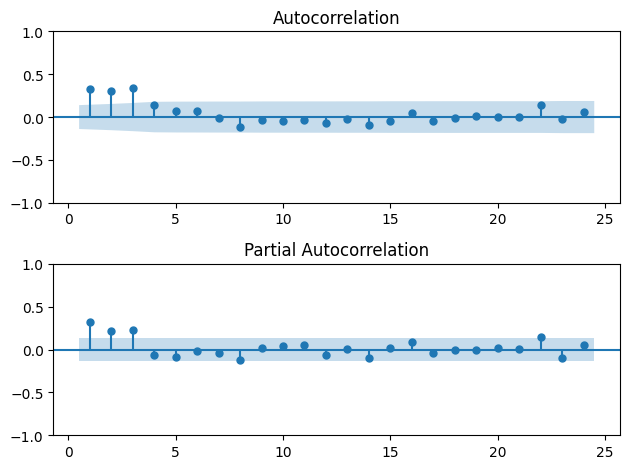

In [46]:
fig, axs = plt.subplots(2)
lags = np.r_[1:25]
sm.graphics.tsa.plot_acf(us_change.Consumption, lags=lags, ax=axs[0]);
sm.graphics.tsa.plot_pacf(us_change.Consumption, lags=lags, ax=axs[1]);
plt.tight_layout()

In [47]:
fit = sm.tsa.SARIMAX(us_change.Consumption, order=(3, 0, 0), trend='c').fit()
display(HTML(fit.summary().as_html()))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.60163D-01    |proj g|=  2.31846D-02

At iterate    5    f=  8.60102D-01    |proj g|=  1.79716D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5      9     11      1     0     0   4.519D-06   8.601D-01
  F =  0.86010071836790825     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


In [48]:
auto_arima_fit = pmd.arima.auto_arima(us_change.Consumption)

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warning

In [50]:
auto_arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  198
Model:               SARIMAX(3, 0, 0)   Log Likelihood                -170.300
Date:                Mon, 07 Apr 2025   AIC                            350.600
Time:                        13:39:33   BIC                            367.041
Sample:                    01-01-1970   HQIC                           357.255
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3045      0.060      5.090      0.000       0.187       0.422
ar.L1          0.2027      0.056      3.648      0.000       0.094       0.312
ar.L2          0.1605      0.055      2.907      0.004       0.052       0.269
ar.L3          0.2252      0.064      3.529      0.000       0.100       0.350
sigma2         0.3264      0.022     14.593      0.000       0.283       0.370
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                74.38
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               0.22   Skew:                            -0.56
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
fit = sm.tsa.SARIMAX(us_change.Consumption, order=(3, 0, 0), trend='c').fit()
display(HTML(fit.summary().as_html()))

## ACF and PACF interpretation

**AR($p$)**

  * ACF dies out in an exponential or damped sine-wave manner
  * PACF has all zero spikes beyond the $p$th spike

So we have an AR($p$) model when

  * the ACF is exponentially decaying or sinusoidal
  * there is a significant spike at lag $p$ in PACF, but none beyond $p$

## ACF and PACF interpretation

**MA($q$)**

 * PACF dies out in an exponential or damped sine-wave manner
 * ACF has all zero spikes beyond the $q$th spike

So we have an MA($q$) model when

  * the PACF is exponentially decaying or sinusoidal
  * there is a significant spike at lag $q$ in ACF, but none beyond $q$

## Information criteria

### Akaike's Information Criterion (AIC):
$\text{AIC} = -2 \log(L) + 2(p+q+k+1),$
where $L$ is the likelihood of the data, $k=1$ if $c\ne0$ and $k=0$ if $c=0$.

### Corrected AIC:
$$\text{AICc} = \text{AIC} + \displaystyle\frac{2(p+q+k+1)(p+q+k+2)}{T-p-q-k-2}.$$

### Bayesian Information Criterion:
$$\text{BIC} = \text{AIC} + [\log(T)-2](p+q+k+1).$$

** Good models are obtained by minimizing either the AIC, $AICc$ or $BIC$. Our preference is to use the $AICc$.

## Procedure for ARIMA

1. Plot the data. Identify any unusual observations.
2. If necessary, transform the data (using a Box-Cox transformation) to stabilize the variance.
3. If the data are non-stationary: take first differences of the data until the data are stationary.
4. Examine the ACF/PACF: Is an AR($p$) or MA($q$) model appropriate?
5. Try your chosen model(s), and use the **AICc** to search for a better model.
6. Check the residuals from your chosen model by plotting the ACF of the residuals, and doing a portmanteau test of the residuals. If they do not look like white noise, try a modified model.
7. Once the residuals look like white noise, calculate forecasts.

## Auto ARIMA

1. Plot the data. Identify any unusual observations.
2. If necessary, transform the data (using a Box-Cox transformation) to stabilize the variance.

3. Use `ARIMA` to automatically select a model.

6. Check the residuals from your chosen model by plotting the ACF of the residuals, and doing a portmanteau test of the residuals. If they do not look like white noise, try a modified model.
7. Once the residuals look like white noise, calculate forecasts.

# Seasonal ARIMA models

## Seasonal ARIMA models

| ARIMA | $~\underbrace{(p, d, q)}$ | $\underbrace{(P, D, Q)_{m}}$ |
| ----: | :-----------------------: | :--------------------------: |
|       | ${\uparrow}$              | ${\uparrow}$                 |
|       | Non-seasonal part         | Seasonal part of             |
|       | of the model              | of the model                 |

where $m =$ number of observations per year.

## Seasonal ARIMA models

E.g., ARIMA$(1, 1, 1)(1, 1, 1)_{4}$ model (without constant)
$$(1 - \phi_{1}B)(1 - \Phi_{1}B^{4}) (1 - B) (1 - B^{4})y_{t} ~= ~
(1 + \theta_{1}B) (1 + \Theta_{1}B^{4})\varepsilon_{t}.
$$

## Seasonal ARIMA models
The seasonal part of an AR or MA model will be seen in the seasonal lags of
the PACF and ACF.

### ARIMA(0,0,0)(0,0,1)$_{12}$ will show:

  * a spike at lag 12 in the ACF but no other significant spikes.
  * The PACF will show exponential decay in the seasonal lags; that is, at lags 12, 24, 36, ...

### ARIMA(0,0,0)(1,0,0)$_{12}$ will show:

  * exponential decay in the seasonal lags of the ACF
  * a single significant spike at lag 12 in the PACF

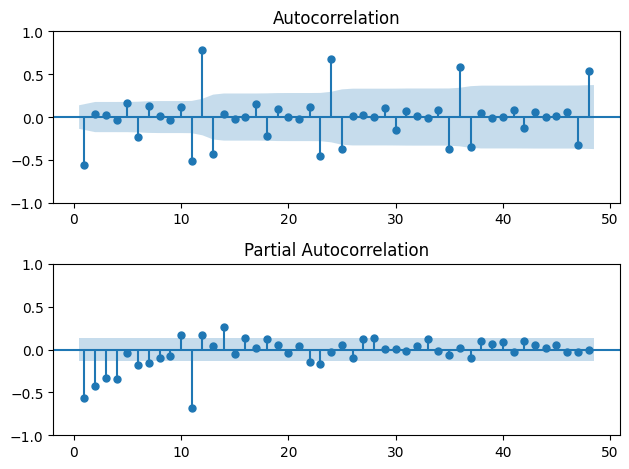

In [51]:
fig, axs = plt.subplots(2)
lags = np.r_[1:4*12+1]
sm.graphics.tsa.plot_acf(a10.Cost.diff().dropna(), lags=lags, ax=axs[0]);
sm.graphics.tsa.plot_pacf(a10.Cost.diff().dropna(), lags=lags, ax=axs[1]);
plt.tight_layout()

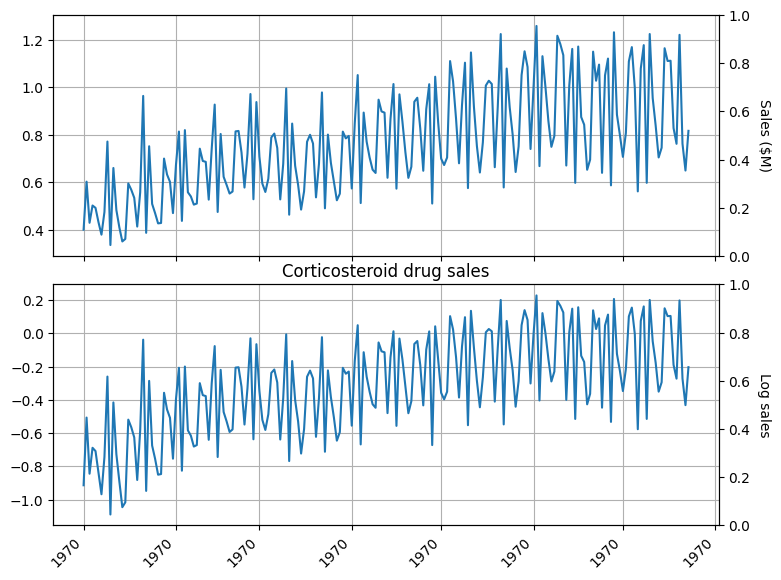

In [52]:
fig, axs = plt.subplots(2, 1, figsize=(8,6), sharex=True)
d = h02
axs[0].plot(d.Cost)
axs[1].plot(np.log(d.Cost))
titles = 'Sales ($M)', 'Log sales', 'Annual $\Delta\ln$', '$\Delta$ Annual $\Delta\ln$'
for ax, title in zip(axs, titles):
    ax2 = ax.twinx()
    ax2.set_ylabel(title, rotation=270, labelpad=15)
    ax2.grid(False)
    ax.grid(True)

axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for label in axs[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')
plt.tight_layout()
plt.title('Corticosteroid drug sales')
fig.subplots_adjust(top=.95)

In [53]:
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

def plot_tsresiduals(Y, y, acf_lags=np.r_[1:26]):
    """Plot timeseries residuals for ground truth Y and estimate y."""
    fig = plt.figure()
    gs = plt.GridSpec(3, 2, figure=fig)
    ts_ax = fig.add_subplot(gs[0,:])
    axs = np.array([ts_ax] + [fig.add_subplot(gs[i,j]) for j in (0,1) for i in (1,2)])
    ax, rax, hax, acfax, pacfax = axs

    mask = ~(np.isnan(Y) | np.isnan(y))
    Y, y = Y[mask], y[mask]
    dy = Y - y

    ax.plot(Y, color='k')
    ax.plot(y)
    ax.set(title='Time Series')

    lim = 1.1 * max(-dy.min(), dy.max())
    lim = -lim, lim

    rax.plot(dy)
    rax.set(ylim=lim, title='Residuals')

    sns.distplot(dy, bins=np.linspace(lim[0], lim[1], 22),
                 hist=True, kde=True, rug=True, ax=hax)
    hax.set(title='Residual Distribution')

    sm.graphics.tsa.plot_acf(dy, lags=acf_lags, ax=acfax)
    sm.graphics.tsa.plot_pacf(dy, lags=acf_lags, ax=pacfax)

    for a in axs.ravel():
        a.grid()

    axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axs[0].xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=6))
    axs[1].xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=6))

    for label in axs[-1].get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

    plt.tight_layout()
    return fig, axs


/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/370474617.py:26: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dy, bins=np.linspace(lim[0], lim[1], 22),


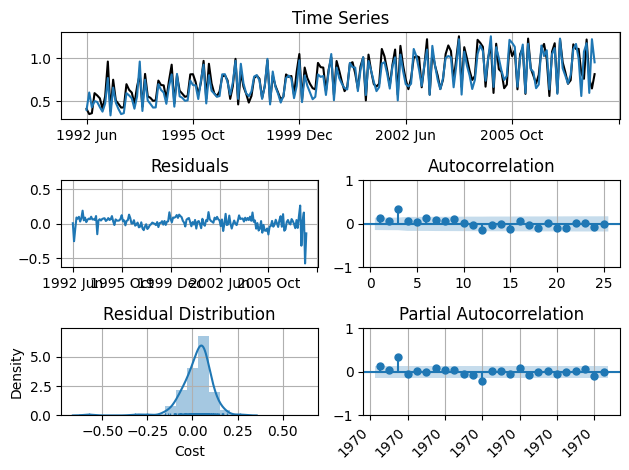

In [54]:
plot_tsresiduals(h02.Cost, h02.Cost.shift(12));

In [55]:
from tqdm import tqdm
import warnings
import itertools


results = []
P, D, d, m = 3, 0, 1, 12
for (Q, p, q) in tqdm(list(itertools.product(range(2), range(3), range(3)))):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = sm.tsa.SARIMAX(np.log(h02.Cost), order=(P,D,Q), seasonal_order=(p,d,q,m)).fit()
        result = dict(P=P, Q=Q, D=D, p=p, d=d, q=q, m=m,
                      label=f'SARIMA({P},{D},{Q})({p}{d}{q}){m}',
                      AIC=fit.aic, fit=fit)
    results.append(result)
results = pd.DataFrame(results)

  6%|██████████▉                                                                                                                                                                                         | 1/18 [00:00<00:03,  4.60it/s]

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -8.05503D-01    |proj g|=  1.13404D+00

At iterate    5    f= -8.08645D-01    |proj g|=  1.34877D-01

At iterate   10    f= -8.10136D-01    |proj g|=  1.76454D-02

At iterate   15    f= -8.10296D-01    |proj g|=  3.22260D-02

At iterate   20    f= -8.10299D-01    |proj g|=  1.84115D-03

At iterate   25    f= -8.10301D-01    |proj g|=  1.12921D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     25     30      1     0     0   

 This problem is unconstrained.



At iterate    5    f= -8.24174D-01    |proj g|=  5.85980D-01

At iterate   10    f= -8.59580D-01    |proj g|=  2.26440D-01

At iterate   15    f= -8.62103D-01    |proj g|=  5.96032D-01

At iterate   20    f= -8.64065D-01    |proj g|=  7.40780D-02

At iterate   25    f= -8.67220D-01    |proj g|=  3.49092D-02


 11%|█████████████████████▊                                                                                                                                                                              | 2/18 [00:01<00:12,  1.29it/s]

...

 94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏          | 17/18 [00:48<00:03,  3.40s/it]


At iterate   50    f= -8.77234D-01    |proj g|=  2.02601D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    8     50     57      1     0     0   2.026D-03  -8.772D-01
  F = -0.87723396945288257     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -8.25670D-01    |proj g|=  8.65169D-01


 This problem is unconstrained.



At iterate    5    f= -8.31652D-01    |proj g|=  8.75917D-01

At iterate   10    f= -8.61316D-01    |proj g|=  7.84580D-02

At iterate   15    f= -8.66026D-01    |proj g|=  3.66565D-01

At iterate   20    f= -8.68867D-01    |proj g|=  3.12233D-01

At iterate   25    f= -8.70402D-01    |proj g|=  1.20134D-01

At iterate   30    f= -8.70618D-01    |proj g|=  1.82795D-02

At iterate   35    f= -8.70959D-01    |proj g|=  6.89475D-03

At iterate   40    f= -8.71072D-01    |proj g|=  2.44146D-02

At iterate   45    f= -8.71330D-01    |proj g|=  1.89210D-02

At iterate   50    f= -8.71415D-01    |proj g|=  5.00717D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:55<00:00,  3.07s/it]


In [56]:
results.sort_values('AIC')['label AIC'.split()]

,label,AIC
8,"SARIMA(3,0,0)(212)12",-347.288456
1,"SARIMA(3,0,0)(011)12",-344.235777
7,"SARIMA(3,0,0)(211)12",-343.430434
2,"SARIMA(3,0,0)(012)12",-343.112250
4,"SARIMA(3,0,0)(111)12",-342.804125
10,"SARIMA(3,0,1)(011)12",-342.264445
16,"SARIMA(3,0,1)(211)12",-341.911460
11,"SARIMA(3,0,1)(012)12",-341.367796
5,"SARIMA(3,0,0)(112)12",-341.322474
13,"SARIMA(3,0,1)(111)12",-340.949214


In [57]:
results[11:12]

,P,Q,D,p,d,q,m,label,AIC,fit
11,3,1,0,0,1,2,12,"SARIMA(3,0,1)(012)12",-341.367796,<statsmodels.tsa.statespace.sarimax.SARIMAXRes...


In [58]:
fit_auto = pmd.auto_arima(
    np.log(h02.Cost),
    seasonal=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warning

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-17.104, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=153.256, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=96.427, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-4.366, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=151.276, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-0.370, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-16.871, Time=0.10 sec


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warning

 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-16.534, Time=0.13 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-13.004, Time=0.10 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=-20.550, Time=0.16 sec


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=-21.862, Time=0.31 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=-18.636, Time=0.13 sec

Best model:  ARIMA(1,1,3)(0,0,0)[0] intercept
Total fit time: 2.012 seconds


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [59]:
display(HTML(fit_auto.summary().as_html()))

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/370474617.py:26: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dy, bins=np.linspace(lim[0], lim[1], 22),


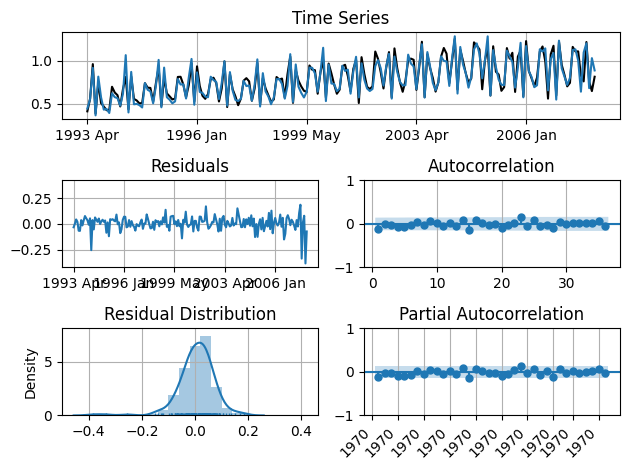

In [60]:
plot_tsresiduals(h02.Cost['1993':], np.exp(results.fit[11].fittedvalues['1993':]),
                 acf_lags=np.r_[1:37]);


/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_10019/370474617.py:26: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dy, bins=np.linspace(lim[0], lim[1], 22),


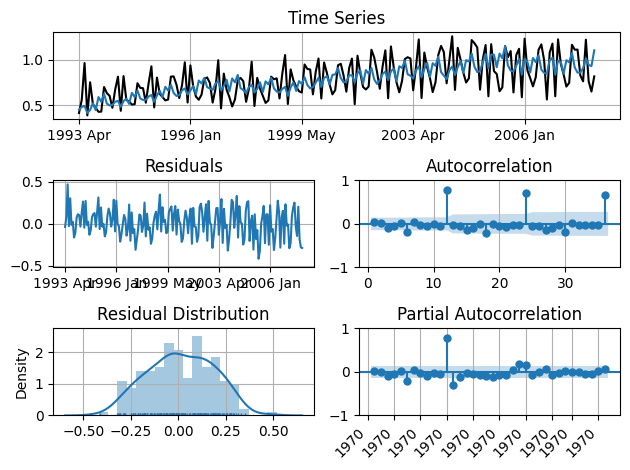

In [61]:
fit = fit_auto.arima_res_
mask = h02.index >= '1993'
ypred = pd.Series(fit.fittedvalues[mask], index=h02.index[mask])
plot_tsresiduals(h02.Cost['1993':], np.exp(ypred),
                 acf_lags=np.r_[1:37]);

In [76]:
split = '2006-06-02'
tend = '2008-06-02'
dtrain, dtest = a10[:split], a10[split:tend]
m = sm.tsa.SARIMAX(np.log1p(dtrain.Cost), order=(3, 0, 1), seasonal_order=(0,1,2,12))
fit = m.fit()

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gabrielasoares/.local/share/virtualenvs/times_series

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.20628D+00    |proj g|=  2.91973D+00


 This problem is unconstrained.



At iterate    5    f= -1.23968D+00    |proj g|=  3.06422D+00

At iterate   10    f= -1.25740D+00    |proj g|=  1.28646D-01

At iterate   15    f= -1.26250D+00    |proj g|=  1.46596D+00

At iterate   20    f= -1.26833D+00    |proj g|=  1.13782D-01

At iterate   25    f= -1.27081D+00    |proj g|=  4.06647D-02

At iterate   30    f= -1.27350D+00    |proj g|=  4.17748D-02

At iterate   35    f= -1.27429D+00    |proj g|=  3.16960D-02

At iterate   40    f= -1.27447D+00    |proj g|=  4.53697D-02

At iterate   45    f= -1.27800D+00    |proj g|=  1.63696D-01


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f= -1.29175D+00    |proj g|=  3.61993D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     50     63      1     0     0   3.620D-01  -1.292D+00
  F =  -1.2917538530514681     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


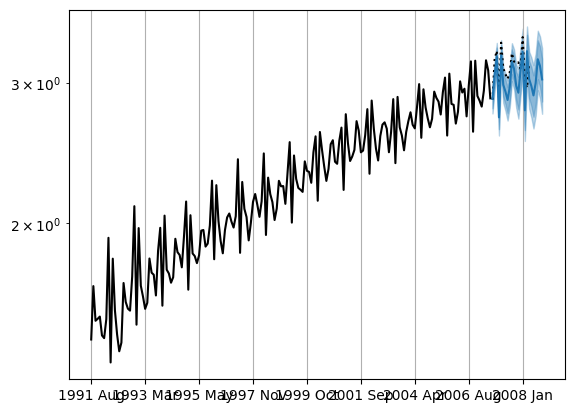

In [78]:
fig, ax = plt.subplots()
ax.plot(np.log1p(dtrain.Cost), 'k')
ax.plot(np.log1p(dtest.Cost), 'k:')
ax.semilogy()

fc = fit.get_forecast(2*12)
ax.plot(fc.predicted_mean)
ci = ciclean(fc.conf_int())
ax.fill_between(fc.predicted_mean.index, ci.lower, ci.upper, color='C0', alpha=.3)
ci = ciclean(fc.conf_int(alpha=.2))
ax.fill_between(fc.predicted_mean.index, ci.lower, ci.upper, color='C0', alpha=.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.grid()

In [79]:
m = sm.tsa.SARIMAX(np.log1p(h02.Cost), order=(3, 0, 1), seasonal_order=(0,1,2,12))
fit = m.fit()

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gabrielasoares/.local/share/virtualenvs/times_series

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.63271D+00    |proj g|=  1.45113D+00

At iterate    5    f= -1.67400D+00    |proj g|=  1.78581D+00

At iterate   10    f= -1.69054D+00    |proj g|=  1.17056D-01

At iterate   15    f= -1.69152D+00    |proj g|=  3.86717D-01

At iterate   20    f= -1.69374D+00    |proj g|=  1.26810D-02

At iterate   25    f= -1.69416D+00    |proj g|=  1.02629D-01

At iterate   30    f= -1.69421D+00    |proj g|=  2.51368D-02



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



At iterate   35    f= -1.69421D+00    |proj g|=  4.05161D-02

At iterate   40    f= -1.69430D+00    |proj g|=  4.64284D-02

At iterate   45    f= -1.69436D+00    |proj g|=  1.53341D-01

At iterate   50    f= -1.69446D+00    |proj g|=  3.51782D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     50     93      2     0     0   3.518D-02  -1.694D+00
  F =  -1.6944569004597405     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


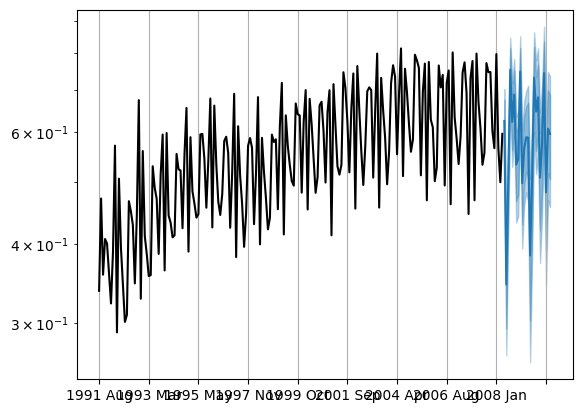

In [80]:
fig, ax = plt.subplots()
ax.plot(np.log1p(h02.Cost), 'k')
ax.semilogy()

fc = fit.get_forecast(2*12)
ax.plot(fc.predicted_mean)
ci = ciclean(fc.conf_int())
ax.fill_between(fc.predicted_mean.index, ci.lower, ci.upper, color='C0', alpha=.3)
ci = ciclean(fc.conf_int(alpha=.2))
ax.fill_between(fc.predicted_mean.index, ci.lower, ci.upper, color='C0', alpha=.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.grid()
